<a href="https://colab.research.google.com/github/sandro-silva/Data/blob/master/tratamento_classificacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EXPLORAÇÃO, ANÁLISE E TRATAMENTO DOS DADOS: PROJETO PREVISÃO DE DOENÇA CARDÍACA**

Este projeto tem por objetivo desenvolver um algoritmo de Machine Learning para prever a tendência de uma pessoa desenvolver algum tipo de doença cardíaca com base em alguns fatores clínicos e laboratoriais de referência.

Os dados foram extraídos do site do Kaggle:

https://www.kaggle.com/fedesoriano/heart-failure-prediction/version/1

In [2]:
import numpy as np
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dados = pd.read_csv('/content/drive/MyDrive/Cursos_Udemy/Machine_Learning_com_Python/heart.csv',
                    sep=',', encoding='iso-8859-1')
# encoding: codificação de caracteres, normalmente utiliza-se o iso-8859-1, utf-8, latin-1)

## **Exploração dos Dados**

In [5]:
dados.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
dados.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [7]:
dados.shape

(918, 12)

## **Análise das Variáveis (Atributos)**

### **Age = idade**

In [8]:
dados['Age'].value_counts()

,count
Age,
54,51
58,42
55,41
56,38
57,38
52,36
62,35
59,35
51,35


In [9]:
dados['Age'].value_counts().sort_index()

,count
Age,
28,1
29,3
30,1
31,2
32,5
33,2
34,7
35,11
36,6


In [10]:
import plotly.express as px

In [11]:
hist1 =  px.histogram (dados,  x = "Age", nbins=60)
hist1.update_layout(width=800,height=500,title_text='Distribuição das idades')
hist1.show()

In [12]:
import seaborn as sns

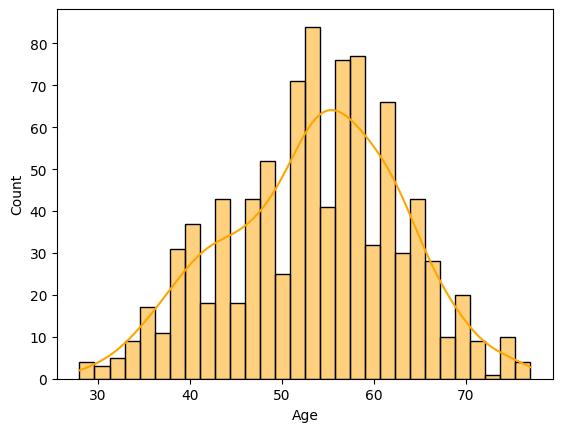

In [13]:
sns.histplot(dados, x='Age', bins=30, color="orange", kde=True, stat="count");

### **Sex = sexo**

In [14]:
dados['Sex'].value_counts()

,count
Sex,
M,725
F,193


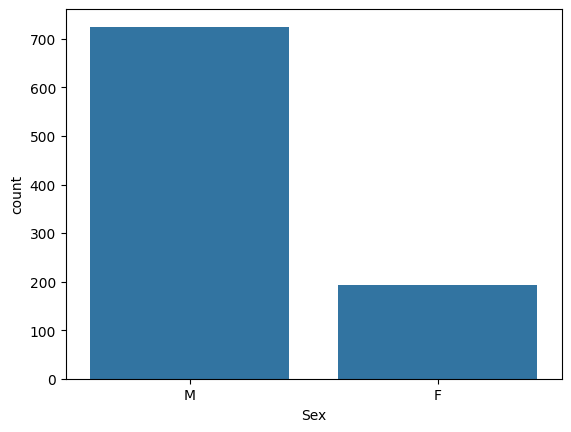

In [15]:
sns.countplot(x='Sex', data=dados);

### **Chest Pain Type = tipo de dor no peito**

In [16]:
dados['ChestPainType'].value_counts()

,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46


ASY: assintomático.

NAP: dor não anginosa.

ATA: angina atípica.

TA: angina típica.







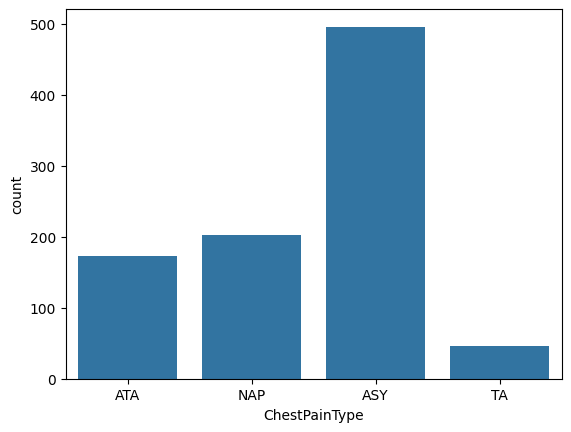

In [17]:
sns.countplot(x='ChestPainType', data=dados);

### **Resting BP (blood pressure) = pressão sanguínea em repouso em mmHg(sistólica)**

In [18]:
dados.RestingBP.value_counts().sort_index()

,count
RestingBP,
0,1
80,1
92,1
94,2
95,6
...,...
180,12
185,1
190,2


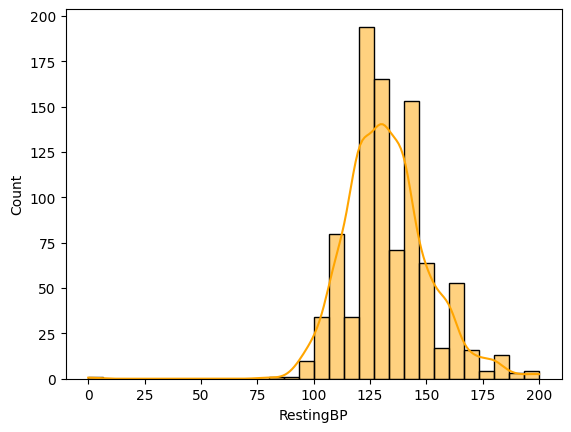

In [19]:
sns.histplot(dados, x='RestingBP', bins=30, color="orange", kde=True, stat="count");

### **Cholesterol = colesterol sérico (mg/dl)**

In [20]:
dados.Cholesterol.value_counts().sort_index()

,count
Cholesterol,
0,172
85,1
100,2
110,1
113,1
...,...
491,1
518,1
529,1


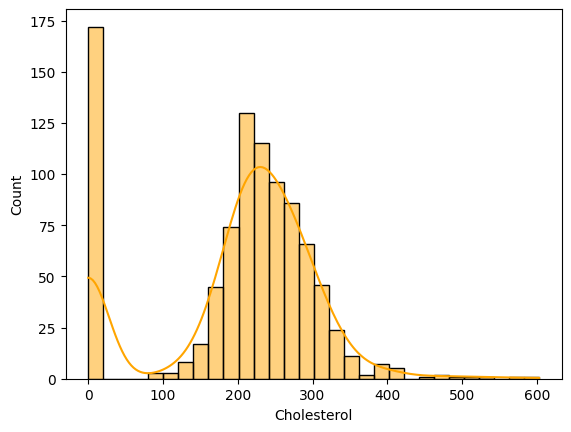

In [21]:
sns.histplot(dados, x='Cholesterol', bins=30, color="orange", kde=True, stat="count");

### **Fasting BS (blood sugar) = açúcar no sangue em jejum (mg/dl)**

In [22]:
dados.FastingBS.value_counts()

,count
FastingBS,
0,704
1,214


0: Fasting BS < 120 mg/dl (não diabético)

1: Fasting BS >= 120 mg/dl, (diabético)

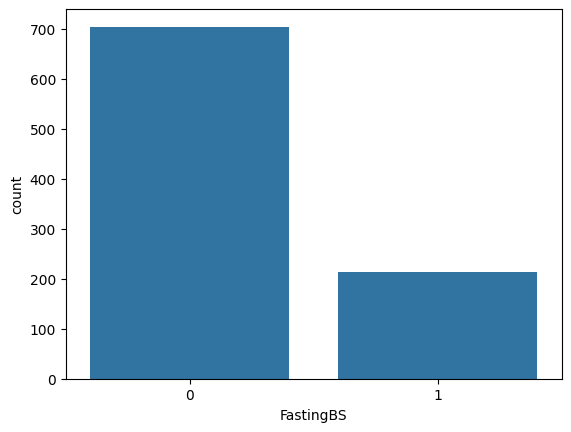

In [23]:
sns.countplot(x='FastingBS', data=dados);

### **Resting ECG = eletrocardiograma em repouso**

In [24]:
dados.RestingECG.value_counts()

,count
RestingECG,
Normal,552
LVH,188
ST,178


Normal: Normal

LVH: Hipertrofia ventricular esquerda

ST: Anormalidade da onda ST-T

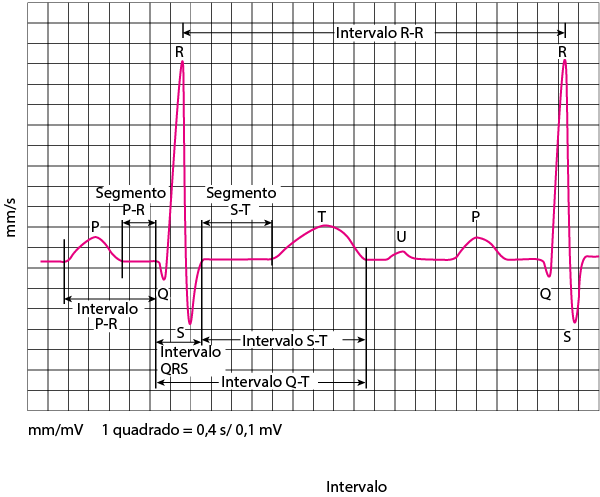

**SEGMENTO ST:** Qualquer desnível do
segmento ST, para cima (supradesnível) ou para baixo
(infradesnível), deve ser avaliado pois pode corresponder a um
infarto agudo do miocárdio.

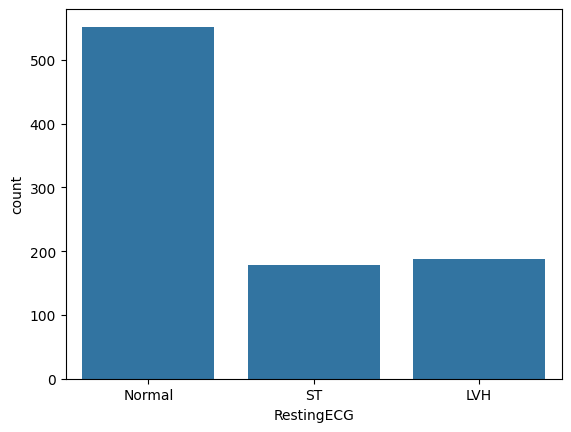

In [25]:
sns.countplot(x='RestingECG', data=dados);

### **Max HR (heart rate) = frequência cardíaca máxima**

In [26]:
dados['MaxHR'].value_counts()

,count
MaxHR,
150,43
140,41
120,36
130,33
160,25
...,...
192,1
195,1
194,1


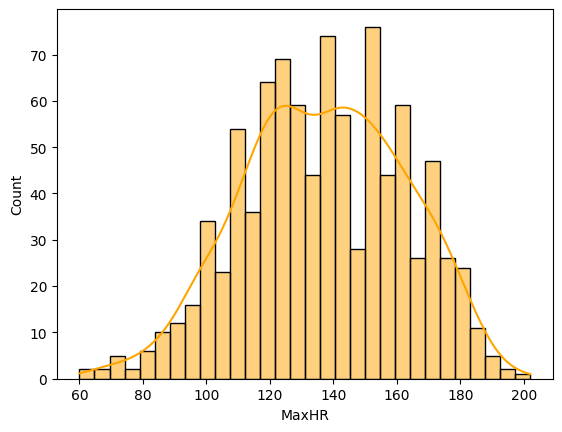

In [27]:
sns.histplot(dados, x='MaxHR', bins=30, color="orange", kde=True, stat="count");

### **Exercise Angina = Angina induzida por exercício**

In [28]:
dados['ExerciseAngina'].value_counts()

,count
ExerciseAngina,
N,547
Y,371


In [29]:
px.pie(dados, 'ExerciseAngina')

### **Old Peak = Depressão de ST (referência no ECG) induzida por exercício em relação ao repouso**

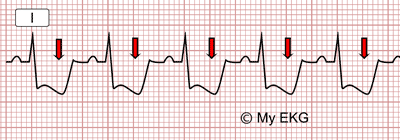

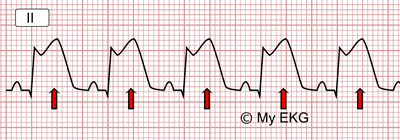

In [30]:
dados['Oldpeak'].value_counts()

,count
Oldpeak,
0.0,368
1.0,86
2.0,76
1.5,53
3.0,28
1.2,26
0.2,22
0.5,19
1.4,18


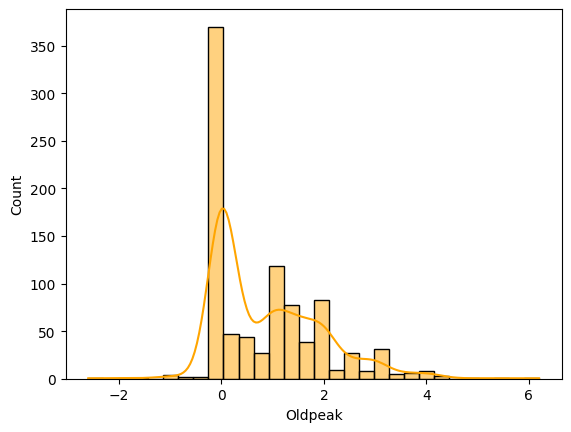

In [31]:
sns.histplot(dados, x='Oldpeak', bins=30, color="orange", kde=True, stat="count");

### **ST_Slope = Inclinação do segmento ST no ECG**

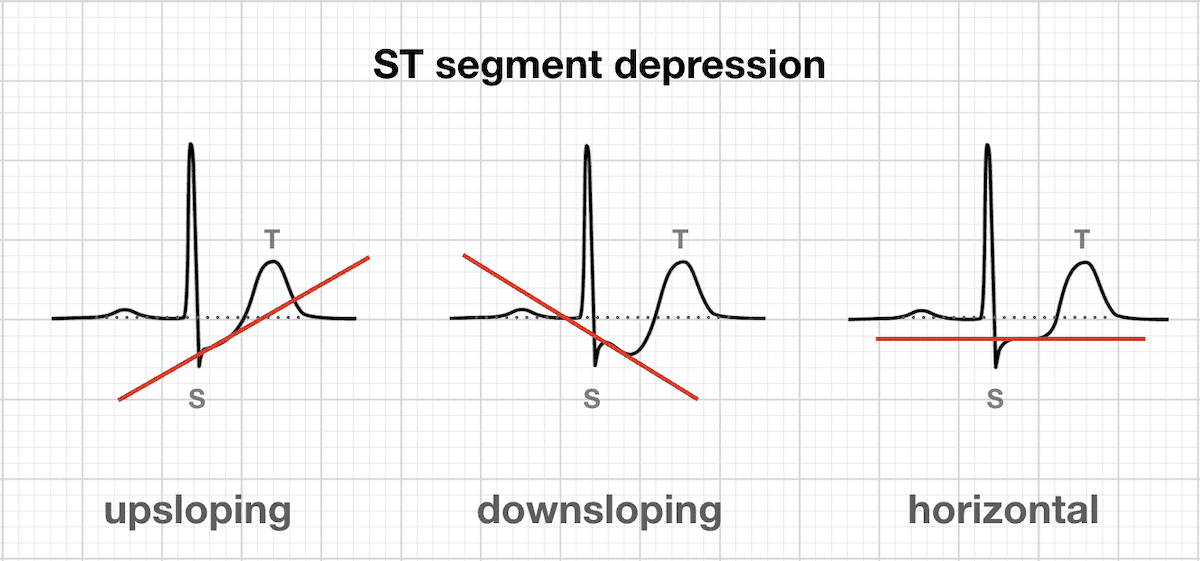

In [32]:
dados['ST_Slope'].value_counts()

,count
ST_Slope,
Flat,460
Up,395
Down,63


Flat = plano

Up = para cima

Down = para baixo

In [33]:
px.pie(dados, 'ST_Slope')

### **Heart Disease = Doença cardíaca**

In [34]:
dados['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


0 = Não possui doença cardíaca

1 = Possui doença cardíaca



In [35]:
px.pie(dados, 'HeartDisease')

## **Análise dos tipos de atributos.**

In [36]:
# object: strings
# int64: inteiros
# float64: reais
# complex: complexos
dados.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


## **Valores Missing (NAN)**

In [37]:
# RELAÇÃO DA QUANTIDADE
dados.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [43]:
# EXCLUIR VALORES MISSING
dados2 = dados.dropna()

In [44]:
dados2.shape

(918, 12)

In [45]:
dados2.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [46]:
# SUBSTITUIR OS VALORES MISSING PELA MÉDIA
dados2['Age'].fillna(dados2['Age'].mean(), inplace=True)

/tmp/ipykernel_1298/635995625.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [47]:
# SUBSTITUIR OS VALORES MISSING POR QUALQUER OUTRO VALOR
dados2['Age'].fillna(10, inplace=True)

/tmp/ipykernel_1298/2566207173.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





## **Análises Estatísticas Descritivas**

In [ ]:
dados.describe()

In [ ]:
dados.mode()

### **Tratando Valores Incoerentes**

**Excluindo registro com pressão zero**

In [ ]:
dados2 = dados.loc[dados.RestingBP != 0]

In [ ]:
dados2.shape

In [ ]:
dados2.describe()

**Substituindo valores zeros do Colesterol pela média sem os zeros**

In [ ]:
dados2.Cholesterol.mean()

In [ ]:
dados2.Cholesterol.replace(0, np.NaN, inplace=True)

In [ ]:
dados2.isnull().sum()

In [ ]:
dados2.Cholesterol.mean()

In [ ]:
# SUBSTITUIR OS VALORES MISSING PELA MÉDIA
dados2['Cholesterol'].fillna(dados2['Cholesterol'].mean(), inplace=True)

In [ ]:
dados2.isnull().sum()

In [ ]:
dados2.describe()

In [ ]:
dados2.mode()

In [ ]:
sns.histplot(dados2, x='Cholesterol', bins=30, color="orange", kde=True, stat="count");

### **Análise de Outliers**

In [ ]:
# Idade
px.box(dados2, y='Age')

In [ ]:
# Pressão Sanguínea em Repouso
px.box(dados2, y='RestingBP')

In [ ]:
# Colesterol
px.box(dados2, y='Cholesterol')

In [ ]:
# Frequência Cardíaca Máxima
px.box(dados2, y='MaxHR')

## **Salvando (Exportando) o Dataframe Tratado**

In [ ]:
dados2.to_csv('heart_tratado.csv', sep=';', encoding='utf-8', index = False)